In [1]:
import pandas as pd
df = pd.read_csv("ai_vs_human_content_v2_20000.csv")
df.head()

,id,prompt,content,type,source,label,topic,word_count,char_count,ai_model,language,complexity_score,is_multiline_code
0,1,Write a string manipulation solution in python,def string_manipulation():\n # TODO: implem...,code,blog,human,string manipulation,9,84,NaN,python,3,True
1,2,Explain health in simple terms,Experts recommend focusing on health to improv...,text,generated,ai,health,29,211,Claude,en,3,False
2,3,Summarize recent developments in finance,The development of finance technologies has ac...,text,generated,ai,finance,56,419,GPT-4,en,5,False
3,4,Summarize recent developments in finance,Recent studies show that finance can have sign...,text,generated,ai,finance,42,298,Claude,en,10,False
4,5,Provide a graph traversal algorithm in cpp,vector<int> arr; // graph traversal example\nf...,code,generated,ai,graph traversal,11,98,Gemini,cpp,10,True


In [2]:
df.columns

Index(['id', 'prompt', 'content', 'type', 'source', 'label', 'topic',
       'word_count', 'char_count', 'ai_model', 'language', 'complexity_score',
       'is_multiline_code'],
      dtype='object')

In [3]:
df = df[['content', 'label']]
df.head()

,content,label
0,def string_manipulation():\n # TODO: implem...,human
1,Experts recommend focusing on health to improv...,ai
2,The development of finance technologies has ac...,ai
3,Recent studies show that finance can have sign...,ai
4,vector<int> arr; // graph traversal example\nf...,ai


In [4]:
df['label'].value_counts()

label
ai       10004
human     9996
Name: count, dtype: int64

In [5]:
df['label'] = df['label'].map({'human': 0, 'ai': 1})

In [6]:
df.head()

,content,label
0,def string_manipulation():\n # TODO: implem...,0
1,Experts recommend focusing on health to improv...,1
2,The development of finance technologies has ac...,1
3,Recent studies show that finance can have sign...,1
4,vector<int> arr; // graph traversal example\nf...,1


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1,2),   
    min_df=2           
)

X = vectorizer.fit_transform(df['content'])
y = df['label']

In [24]:
X.shape

(20000, 268)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [29]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9995


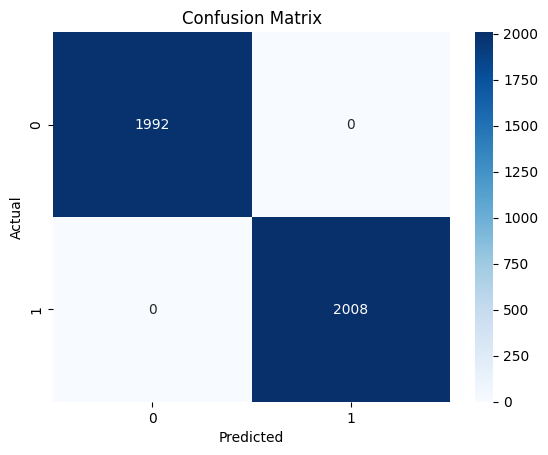

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1992
           1       1.00      1.00      1.00      2008

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

